# 07 - Threshold Selection and Business Costing

This notebook converts model scores from Notebook 06 into a defensible credit-risk operating policy.

Notebook 06 answered: **which model ranks borrowers best?**  
Notebook 07 answers: **which score threshold should the business use, given credit losses, customer friction, and review capacity?**

## 1. Professional thresholding principles

A probability model is not a business decision until the operating threshold is selected. In credit-risk review, threshold choice controls four competing outcomes:

- **True positives:** likely defaulters correctly routed to review.
- **False negatives:** future defaulters missed by the model.
- **False positives:** non-defaulters routed to unnecessary review.
- **True negatives:** non-defaulters correctly allowed to pass without review.

This notebook follows a model-risk-safe design:

1. Use **validation data only** to select the model-threshold pair.
2. Use the **test set only once** to confirm the selected operating rule.
3. Separate the **ranking champion** from the **operational champion**.
4. Document stakeholder impact, review capacity, and cost assumptions.
5. Create a clean handoff to Notebook 08 for explainability.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from credit_risk.config import TABLE_DIR, ensure_project_directories
from credit_risk.models.thresholding import (
    ThresholdCostAssumptions,
    apply_recommendation_to_threshold_grid,
    build_all_model_operational_threshold_comparison,
    build_cost_sensitivity_scenarios,
    build_metric_stakeholder_impact_summary,
    build_model_handoff_for_explainability,
    build_policy_option_table,
    build_threshold_grid,
    build_threshold_policy_decision_table,
    build_threshold_readiness_gate,
    cost_assumptions_frame,
    evaluate_threshold_grid_all_models,
    make_confusion_matrix_long,
    read_first_existing_csv,
    recommend_operational_model_threshold,
    run_business_cost_sensitivity_analysis,
    save_threshold_outputs,
)

ensure_project_directories()
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

## 2. Load Notebook 06 prediction outputs

The thresholding notebook uses prediction files created by Notebook 06. It supports both the final `06_` filenames and older compatible filenames.

In [2]:
validation_predictions = read_first_existing_csv([
    TABLE_DIR / "06_validation_predictions_default_threshold.csv",
    TABLE_DIR / "validation_predictions_default_threshold.csv",
])

test_predictions = read_first_existing_csv([
    TABLE_DIR / "06_test_predictions_default_threshold.csv",
    TABLE_DIR / "test_predictions_default_threshold.csv",
])

validation_results = read_first_existing_csv([
    TABLE_DIR / "06_model_validation_results_default_threshold.csv",
    TABLE_DIR / "model_validation_results_default_threshold.csv",
], required=False)

print("Validation predictions:", validation_predictions.shape)
print("Test predictions:", test_predictions.shape)
print("Validation model results:", validation_results.shape)

validation_predictions.head()

Validation predictions: (120978, 7)
Test predictions: (120978, 7)
Validation model results: (6, 21)


,user_id,record_sequence,defaulter,split,model_name,predicted_default_probability,predicted_label_at_0_5
0,7013527,1,1,validation,logistic_regression_train_only_baseline,0.522228,1
1,7014312,1,0,validation,logistic_regression_train_only_baseline,0.503159,1
2,7033834,1,0,validation,logistic_regression_train_only_baseline,0.108527,0
3,6643246,1,0,validation,logistic_regression_train_only_baseline,0.688296,1
4,7033844,1,0,validation,logistic_regression_train_only_baseline,0.778254,1


## 3. Review default-threshold model results

The 0.50 threshold is useful as a diagnostic baseline, but it is not automatically the correct business threshold. The final threshold must be selected using validation-set cost and review-capacity analysis.

In [3]:
if not validation_results.empty:
    display_cols = [
        "model_name", "pr_auc", "roc_auc", "brier_score", "recall", "precision",
        "f1", "mcc", "review_rate", "business_cost", "false_negative", "false_positive",
    ]
    validation_results[[c for c in display_cols if c in validation_results.columns]].sort_values("pr_auc", ascending=False)
else:
    print("No validation-results summary file found. Proceeding with prediction-level threshold analysis.")

## 4. Define business-cost assumptions

The costs below are **scenario assumptions**, not accounting estimates. They make threshold trade-offs explicit:

- A **false negative** is a borrower who later defaults but was not routed to review.
- A **false positive** is a non-default borrower routed to unnecessary review.

These values should be stress-tested later with sensitivity analysis.

In [4]:
cost_assumptions = ThresholdCostAssumptions(false_negative_cost=5_000, false_positive_cost=500)
review_rate_cap = 0.30
min_recall = 0.60

cost_assumptions_df = cost_assumptions_frame(cost_assumptions)
cost_assumptions_df

,assumption,value,description
0,false_negative_cost,5000.000000,Illustrative cost of missing a borrower who la...
1,false_positive_cost,500.000000,Illustrative operational and customer-friction...
2,calibrated_probability_cost_ratio_threshold,0.090909,Theoretical cutoff if model probabilities were...


## 5. Evaluate threshold grid for every model

Every model is evaluated across the same threshold grid. Selection is performed on validation data only.

In [5]:
thresholds = build_threshold_grid(start=0.01, stop=0.99, step=0.005)

validation_threshold_grid = evaluate_threshold_grid_all_models(
    validation_predictions,
    thresholds=thresholds,
    dataset_name="validation",
    cost_assumptions=cost_assumptions,
)

test_threshold_grid = evaluate_threshold_grid_all_models(
    test_predictions,
    thresholds=thresholds,
    dataset_name="test",
    cost_assumptions=cost_assumptions,
)

print("Validation threshold rows:", validation_threshold_grid.shape)
print("Test threshold rows:", test_threshold_grid.shape)
validation_threshold_grid.head()

Validation threshold rows: (1182, 21)
Test threshold rows: (1182, 21)


,model_name,dataset,threshold,roc_auc,pr_auc,brier_score,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,review_rate,business_cost,true_negative,false_positive,false_negative,true_positive,default_count,non_default_count
0,logistic_regression_train_only_baseline,validation,0.010,0.743584,0.220994,0.208448,0.090413,0.500000,0.090413,1.0,0.000000,0.165833,0.000000,1.000000,9170000.0,0,18340,0,1823,1823,18340
1,logistic_regression_train_only_baseline,validation,0.015,0.743584,0.220994,0.208448,0.090413,0.500000,0.090413,1.0,0.000000,0.165833,0.000000,1.000000,9170000.0,0,18340,0,1823,1823,18340
2,logistic_regression_train_only_baseline,validation,0.020,0.743584,0.220994,0.208448,0.090413,0.500000,0.090413,1.0,0.000000,0.165833,0.000000,1.000000,9170000.0,0,18340,0,1823,1823,18340
3,logistic_regression_train_only_baseline,validation,0.025,0.743584,0.220994,0.208448,0.090612,0.500109,0.090431,1.0,0.000218,0.165863,0.004441,0.999802,9168000.0,4,18336,0,1823,1823,18340
4,logistic_regression_train_only_baseline,validation,0.030,0.743584,0.220994,0.208448,0.090810,0.500218,0.090449,1.0,0.000436,0.165893,0.006281,0.999603,9166000.0,8,18332,0,1823,1823,18340


## 6. Select the operational champion on validation data

Professional model selection separates two concepts:

- **Ranking champion:** best validation PR-AUC or ROC-AUC.
- **Operational champion:** best model-threshold pair under business constraints.

The default policy here minimizes business cost subject to:

```text
review_rate <= 30%
minimum recall >= 60%
```

In [6]:
all_model_operational_comparison = build_all_model_operational_threshold_comparison(
    threshold_grid=validation_threshold_grid,
    validation_results=validation_results,
    review_rate_cap=review_rate_cap,
    min_recall=min_recall,
    objective_name="minimum_cost_review_rate_le_30pct",
)

operational_recommendation = recommend_operational_model_threshold(all_model_operational_comparison)

display_cols = [
    "operational_rank", "model_name", "threshold", "pr_auc", "roc_auc", "recall",
    "precision", "review_rate", "business_cost", "false_negative", "false_positive",
    "validation_pr_auc_at_default_threshold", "selection_basis",
]
all_model_operational_comparison[[c for c in display_cols if c in all_model_operational_comparison.columns]]

,operational_rank,model_name,threshold,pr_auc,roc_auc,recall,precision,review_rate,business_cost,false_negative,false_positive,validation_pr_auc_at_default_threshold,selection_basis
0,1,xgboost_weighted_baseline,0.560,0.226251,0.751186,0.625891,0.190484,0.297079,5834500.0,682,4849,0.226251,minimum business cost under review_rate <= 30%...
1,2,xgboost_hyperopt_tuned,0.565,0.230267,0.752052,0.616566,0.189609,0.294004,5897000.0,699,4804,0.230267,minimum business cost under review_rate <= 30%...
2,3,xgboost_hyperopt_tuned_skew_treated,0.565,0.230535,0.752131,0.615469,0.189335,0.293905,5907000.0,701,4804,0.230535,minimum business cost under review_rate <= 30%...
3,4,random_forest_random_search_tuned,0.545,0.224728,0.750774,0.618760,0.187656,0.298120,5916500.0,695,4883,0.224728,minimum business cost under review_rate <= 30%...
4,5,random_forest_weighted_baseline,0.545,0.223822,0.745802,0.607789,0.190247,0.288846,5933000.0,715,4716,0.223822,minimum business cost under review_rate <= 30%...
5,6,logistic_regression_train_only_baseline,0.550,0.220994,0.743584,0.607789,0.185315,0.296533,6010500.0,715,4871,0.220994,minimum business cost under review_rate <= 30%...


## 7. Confirm the selected operating rule on the test set

The test set is not used to choose the threshold. It is used here only to confirm how the validation-selected operating rule behaves out of sample.

In [7]:
test_confirmation = apply_recommendation_to_threshold_grid(
    recommendation=operational_recommendation,
    threshold_grid=test_threshold_grid,
    dataset_name="test",
)

print("Validation-selected operating rule:")
display(operational_recommendation[[c for c in display_cols if c in operational_recommendation.columns]])

print("Test confirmation:")
display(test_confirmation[[c for c in display_cols if c in test_confirmation.columns]])

Validation-selected operating rule:


,operational_rank,model_name,threshold,pr_auc,roc_auc,recall,precision,review_rate,business_cost,false_negative,false_positive,validation_pr_auc_at_default_threshold,selection_basis
0,1,xgboost_weighted_baseline,0.56,0.226251,0.751186,0.625891,0.190484,0.297079,5834500.0,682,4849,0.226251,minimum business cost under review_rate <= 30%...


Test confirmation:


,model_name,threshold,pr_auc,roc_auc,recall,precision,review_rate,business_cost,false_negative,false_positive
0,xgboost_weighted_baseline,0.56,0.214653,0.747839,0.622052,0.190877,0.294649,5848500.0,689,4807


## 8. Confusion matrix analysis

The confusion matrix translates model performance into business outcomes. For credit risk, the most important cells are usually:

- **False negatives:** missed future defaults.
- **False positives:** unnecessary reviews.

In [8]:
validation_confusion = make_confusion_matrix_long(operational_recommendation, dataset_name="validation")
test_confusion = make_confusion_matrix_long(test_confirmation, dataset_name="test")

pd.concat([validation_confusion, test_confusion], ignore_index=True)

,dataset,model_name,threshold,actual,predicted,count,cell
0,validation,xgboost_weighted_baseline,0.56,non_default,non_default,13491,true_negative
1,validation,xgboost_weighted_baseline,0.56,non_default,default_review,4849,false_positive
2,validation,xgboost_weighted_baseline,0.56,default,non_default,682,false_negative
3,validation,xgboost_weighted_baseline,0.56,default,default_review,1141,true_positive
4,test,xgboost_weighted_baseline,0.56,non_default,non_default,13533,true_negative
5,test,xgboost_weighted_baseline,0.56,non_default,default_review,4807,false_positive
6,test,xgboost_weighted_baseline,0.56,default,non_default,689,false_negative
7,test,xgboost_weighted_baseline,0.56,default,default_review,1134,true_positive


## 9. Stakeholder impact of metrics

Metrics should be interpreted differently for different stakeholders:

- Credit risk cares about missed defaults and loss prevention.
- Operations cares about review volume.
- Customers are affected by unnecessary friction.
- Regulators and model-risk teams care about explainability, fairness, stability, and documented trade-offs.

In [9]:
stakeholder_summary = build_metric_stakeholder_impact_summary(test_confirmation)
stakeholder_summary

,metric,selected_value,business_meaning,stakeholder_impact
0,Recall,6.220516e-01,Share of actual defaulters captured for review.,Higher recall helps credit risk teams reduce m...
1,Precision,1.908770e-01,Share of reviewed borrowers who actually default.,Higher precision reduces unnecessary reviews a...
2,False negatives,6.890000e+02,Defaulters not sent for review.,Creates credit-loss exposure and is usually mo...
3,False positives,4.807000e+03,Non-defaulters sent for review.,Creates operational workload and may create cu...
4,Review rate,2.946486e-01,Share of accounts routed to manual/risk review.,Must fit available credit operations capacity ...
5,Business cost,5.848500e+06,Scenario-weighted cost of false negatives and ...,"Allows credit risk, operations, and business l..."


## 10. Threshold trade-off visualization

The plots below show how recall, precision, review rate, and business cost move as the threshold changes for the selected operating model.

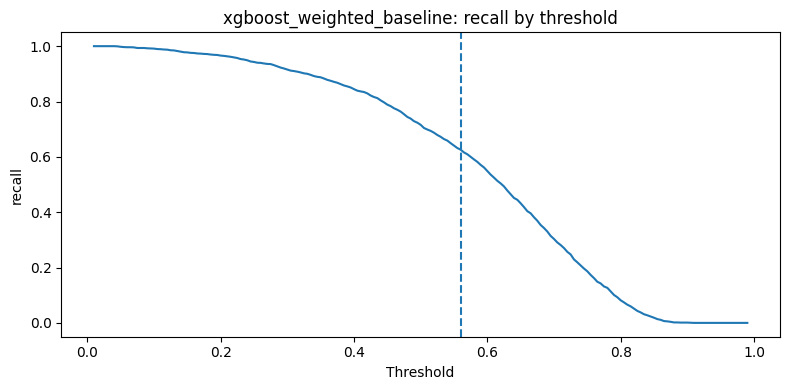

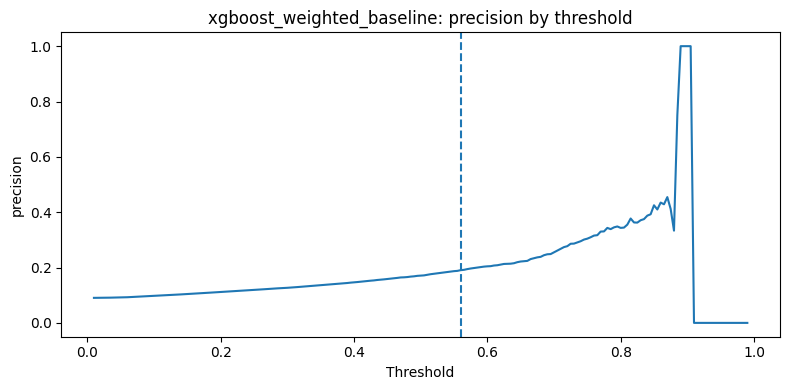

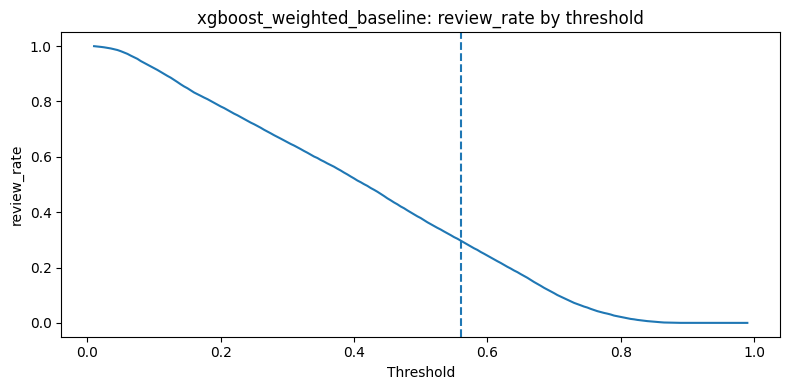

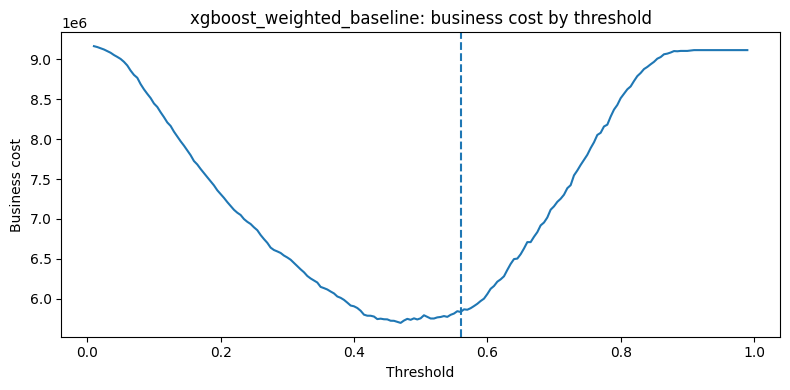

In [10]:
selected_model = str(operational_recommendation.iloc[0]["model_name"])
selected_threshold = float(operational_recommendation.iloc[0]["threshold"])
selected_grid = validation_threshold_grid.loc[validation_threshold_grid["model_name"].eq(selected_model)].copy()

plot_cols = ["recall", "precision", "review_rate"]
for col in plot_cols:
    plt.figure(figsize=(8, 4))
    plt.plot(selected_grid["threshold"], selected_grid[col])
    plt.axvline(selected_threshold, linestyle="--")
    plt.title(f"{selected_model}: {col} by threshold")
    plt.xlabel("Threshold")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 4))
plt.plot(selected_grid["threshold"], selected_grid["business_cost"])
plt.axvline(selected_threshold, linestyle="--")
plt.title(f"{selected_model}: business cost by threshold")
plt.xlabel("Threshold")
plt.ylabel("Business cost")
plt.tight_layout()
plt.show()

## 11. Business-cost sensitivity analysis

Threshold recommendations can change when false-negative and false-positive cost assumptions change. A professional threshold policy should therefore be stress-tested.

In [11]:
cost_sensitivity = run_business_cost_sensitivity_analysis(
    validation_predictions=validation_predictions,
    validation_results=validation_results,
    thresholds=thresholds,
    review_rate_cap=review_rate_cap,
    min_recall=min_recall,
    scenarios=build_cost_sensitivity_scenarios(),
)

cols = [
    "scenario_name", "false_negative_cost", "false_positive_cost", "model_name", "threshold",
    "recall", "precision", "review_rate", "business_cost",
]
cost_sensitivity[[c for c in cols if c in cost_sensitivity.columns]].head(20)

,scenario_name,false_negative_cost,false_positive_cost,model_name,threshold,recall,precision,review_rate,business_cost
0,fn_2500_fp_250,2500.0,250.0,xgboost_weighted_baseline,0.560,0.625891,0.190484,0.297079,2917250.0
1,fn_2500_fp_500,2500.0,500.0,xgboost_weighted_baseline,0.575,0.600110,0.196515,0.276100,4059000.0
2,fn_2500_fp_1000,2500.0,1000.0,xgboost_weighted_baseline,0.575,0.600110,0.196515,0.276100,6295500.0
3,fn_5000_fp_250,5000.0,250.0,xgboost_weighted_baseline,0.560,0.625891,0.190484,0.297079,4622250.0
4,fn_5000_fp_500,5000.0,500.0,xgboost_weighted_baseline,0.560,0.625891,0.190484,0.297079,5834500.0
5,fn_5000_fp_1000,5000.0,1000.0,xgboost_weighted_baseline,0.575,0.600110,0.196515,0.276100,8118000.0
6,fn_7500_fp_250,7500.0,250.0,xgboost_weighted_baseline,0.560,0.625891,0.190484,0.297079,6327250.0
7,fn_7500_fp_500,7500.0,500.0,xgboost_weighted_baseline,0.560,0.625891,0.190484,0.297079,7539500.0
8,fn_7500_fp_1000,7500.0,1000.0,xgboost_weighted_baseline,0.575,0.600110,0.196515,0.276100,9940500.0
9,fn_10000_fp_250,10000.0,250.0,xgboost_weighted_baseline,0.560,0.625891,0.190484,0.297079,8032250.0


## 12. Business policy options

Different stakeholders may prefer different operating policies. This table shows practical alternatives instead of pretending there is only one universally correct threshold.

In [12]:
policy_options = build_policy_option_table(validation_threshold_grid, validation_results)
policy_display_cols = [
    "objective", "model_name", "threshold", "recall", "precision", "review_rate", "business_cost",
    "review_rate_cap", "min_recall_floor", "policy_description",
]
policy_options[[c for c in policy_display_cols if c in policy_options.columns]]

,objective,model_name,threshold,recall,precision,review_rate,business_cost,review_rate_cap,min_recall_floor,policy_description
0,capacity_constrained,xgboost_hyperopt_tuned_skew_treated,0.600,0.562809,0.205447,0.247681,5969000.0,0.25,0.55,Conservative review workload; may miss more de...
1,balanced_operating_policy,xgboost_weighted_baseline,0.560,0.625891,0.190484,0.297079,5834500.0,0.30,0.60,Balanced risk capture and operational capacity.
2,risk_capture_policy,random_forest_random_search_tuned,0.515,0.681295,0.179558,0.343054,5742500.0,0.35,0.65,More default capture with higher review workload.
3,high_recall_policy,random_forest_random_search_tuned,0.490,0.733406,0.171939,0.385657,5649500.0,0.40,0.70,Higher risk capture; greater customer/operatio...


## 13. Final threshold policy decision

This table summarizes the decision in a form suitable for a model card, stakeholder deck, or model-risk documentation.

In [13]:
threshold_policy_decision_table = build_threshold_policy_decision_table(
    validation_recommendation=operational_recommendation,
    test_confirmation=test_confirmation,
)
threshold_policy_decision_table

,decision_item,decision,evidence
0,Operating model,xgboost_weighted_baseline,Selected on validation data using the business...
1,Operating threshold,0.56,Validation-selected threshold; test set used o...
2,Validation recall,0.625891,Risk-capture level at the selected threshold.
3,Validation precision,0.190484,Review efficiency at the selected threshold.
4,Validation review rate,0.297079,Operational workload estimate under the select...
5,Test recall,0.622052,Out-of-sample confirmation of risk capture.
6,Test precision,0.190877,Out-of-sample confirmation of review efficiency.
7,Test business cost,5848500.0,Out-of-sample confirmation of cost trade-off.
8,Proceed to explainability,Yes,Selected model and threshold are documented fo...


## 14. Handoff to Explainable AI notebook

Notebook 08 should explain the selected **operational model and threshold**, not just the highest PR-AUC model. This ensures SHAP, Anchors, and counterfactual explanations match the actual business operating rule.

In [14]:
model_handoff_for_explainability = build_model_handoff_for_explainability(
    validation_recommendation=operational_recommendation,
    test_confirmation=test_confirmation,
)
model_handoff_for_explainability

,handoff_item,value,description
0,operational_model_name,xgboost_weighted_baseline,Model to explain in Notebook 08.
1,operating_threshold,0.56,Threshold to use when labeling review/non-revi...
2,test_recall,0.622052,Out-of-sample risk capture rate at selected th...
3,test_precision,0.190877,Out-of-sample review efficiency at selected th...
4,test_review_rate,0.294649,Out-of-sample share routed to review.


## 15. Save Notebook 07 outputs

All saved outputs use a `07_` prefix so downstream notebooks can clearly trace which step created each file.

In [15]:
readiness_gate = build_threshold_readiness_gate(
    validation_grid=validation_threshold_grid,
    test_grid=test_threshold_grid,
    recommendation=operational_recommendation,
    test_confirmation=test_confirmation,
)

outputs = {
    "07_business_cost_assumptions.csv": cost_assumptions_df,
    "07_threshold_grid_validation_all_models.csv": validation_threshold_grid,
    "07_threshold_grid_test_all_models.csv": test_threshold_grid,
    "07_all_model_operational_threshold_comparison_validation.csv": all_model_operational_comparison,
    "07_operational_threshold_recommendation_validation.csv": operational_recommendation,
    "07_test_confirmation_selected_operational_model.csv": test_confirmation,
    "07_policy_option_table_validation.csv": policy_options,
    "07_business_cost_sensitivity_validation.csv": cost_sensitivity,
    "07_confusion_matrix_selected_validation.csv": validation_confusion,
    "07_confusion_matrix_selected_test.csv": test_confusion,
    "07_stakeholder_metric_impact_summary.csv": stakeholder_summary,
    "07_threshold_policy_decision_table.csv": threshold_policy_decision_table,
    "07_model_handoff_for_explainability.csv": model_handoff_for_explainability,
    "07_threshold_readiness_gate.csv": readiness_gate,
}

save_threshold_outputs(TABLE_DIR, outputs)
readiness_gate

,check,passed,note
0,validation_threshold_grid_created,True,Thresholds evaluated on validation predictions.
1,test_threshold_grid_created,True,Test threshold grid created for confirmation o...
2,operational_recommendation_created,True,Operational model-threshold selected from vali...
3,test_confirmation_created,True,Selected threshold confirmed on test set.
4,review_rate_documented,True,Manual review workload is documented.
5,business_cost_documented,True,Cost trade-off is documented.
6,ready_for_explainability,True,Notebook 08 can explain the selected operation...


## 16. Notebook 07 conclusion

Notebook 07 selects the operating model-threshold pair using validation data, confirms it on the test set, documents the business-cost trade-off, and creates a clean handoff to explainability.

The next notebook should focus on explaining the selected operational decision rule using SHAP, Anchors, and counterfactuals.